### Question 1
Implement a K-Nearest Neighbors (KNN) classifier in Python to predict whether a Flipkart product review is 'positive' or 'negative' using a small dataset of review texts and their labels.

*(Hint: Use scikit-learn's KNeighborsClassifier and convert the text data into numerical features using CountVectorizer.)*

`CountVectorizer` converts the collection of text reviews into a sparse token frequency matrix. `KNeighborsClassifier` classifies unseen reviews by computing the distance (e.g., Euclidean or cosine-equivalent) to the $k$ closest labeled text vectors in the bag-of-words space and taking a majority vote.

In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# 1. Mock dataset of Flipkart product reviews
reviews = [
    "This product is amazing and works perfectly",
    "Terrible quality, broke within two days of delivery",
    "Value for money, great battery backup and design",
    "Worst purchase ever, completely fake item received",
    "Loved the build quality, highly recommended to everyone",
    "Horrible experience, customer care did not help at all",
    "Super fast delivery and outstanding packaging",
    "Defective item received and very poor sound quality",
    "Excellent performance, totally satisfied with Flipkart",
    "Waste of hard earned money, disappointed with this product"
]
labels = ["positive", "negative", "positive", "negative", "positive", 
          "negative", "positive", "negative", "positive", "negative"]

# 2. Convert text to bag-of-words feature matrix
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(reviews)

# 3. Fit KNN classifier (k=3)
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, labels)

# 4. Test predictions on new sample reviews
test_reviews = [
    "Great quality and amazing battery backup",
    "Defective and worst purchase ever"
]
X_test = vectorizer.transform(test_reviews)
predictions = knn_model.predict(X_test)

for rev, pred in zip(test_reviews, predictions):
    print(f"Review: '{rev}' -> Predicted Sentiment: [{pred.upper()}]")

Review: 'Great quality and amazing battery backup' -> Predicted Sentiment: [POSITIVE]
Review: 'Defective and worst purchase ever' -> Predicted Sentiment: [NEGATIVE]


### Question 2
Compare the accuracy of KNN using Euclidean distance vs. Manhattan distance on a dataset of Spotify song features (e.g., tempo, danceability, energy) to classify songs as 'workout' or 'chill' playlists.

*(Hint: Use the 'metric' parameter in KNeighborsClassifier to switch between 'euclidean' and 'manhattan'.)*

Euclidean distance ($L_2 = \sqrt{\sum (x_i - y_i)^2}$) measures straight-line geometric distance, making it sensitive to extreme differences in individual attributes like tempo. Manhattan distance ($L_1 = \sum |x_i - y_i|$) computes grid-based absolute coordinate differences, which is more robust to outlier feature dimensions. Standardizing features allows both metrics to evaluate danceability, energy, and tempo on equal footing.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Generate synthetic Spotify playlist features (tempo, energy, danceability)
np.random.seed(42)
# Workout playlist: High tempo (125-180 BPM), high energy (0.7-1.0), high danceability (0.6-0.9)
tempo_w = np.random.uniform(125, 180, 35)
energy_w = np.random.uniform(0.70, 0.98, 35)
dance_w = np.random.uniform(0.60, 0.90, 35)

# Chill playlist: Low-to-moderate tempo (70-110 BPM), low energy (0.2-0.55), moderate danceability (0.3-0.65)
tempo_c = np.random.uniform(70, 110, 35)
energy_c = np.random.uniform(0.20, 0.55, 35)
dance_c = np.random.uniform(0.30, 0.65, 35)

X = np.vstack([
    np.column_stack([tempo_w, energy_w, dance_w]),
    np.column_stack([tempo_c, energy_c, dance_c])
])
y = np.array(["workout"] * 35 + ["chill"] * 35)

# 2. Split and scale features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Fit KNN with Euclidean (L2) distance
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train_scaled, y_train)
acc_euclidean = accuracy_score(y_test, knn_euclidean.predict(X_test_scaled))

# 4. Fit KNN with Manhattan (L1) distance
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)
acc_manhattan = accuracy_score(y_test, knn_manhattan.predict(X_test_scaled))

results_df = pd.DataFrame({
    'Distance Metric': ['Euclidean (L2)', 'Manhattan (L1)'],
    'Formula': ['sqrt(sum((x - y)^2))', 'sum(|x - y|)'],
    'Test Accuracy': [f"{acc_euclidean * 100:.2f}%", f"{acc_manhattan * 100:.2f}%"]
})
display(results_df)

,Distance Metric,Formula,Test Accuracy
0,Euclidean (L2),sqrt(sum((x - y)^2)),100.00%
1,Manhattan (L1),sum(|x - y|),100.00%


### Question 3
Use Gaussian Naive Bayes to classify whether an IRCTC train booking is likely to be 'confirmed' or 'waitlisted' based on features like booking time, train popularity, and travel day (use a small mock dataset).

Gaussian Naive Bayes assumes each continuous feature follows a normal distribution conditioned on the class: $P(x_i | y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)$. By combining prior class probabilities with feature likelihoods under the conditional independence assumption, it predicts booking confirmation likelihood.

In [3]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Mock IRCTC booking dataset
# Features: [days_booked_before_travel (1-60), train_popularity_rating (1-10), day_of_week (1=Mon, 7=Sun)]
np.random.seed(42)
n_records = 100
days_before = np.random.randint(1, 60, n_records)
popularity = np.random.uniform(1.0, 10.0, n_records)
travel_day = np.random.randint(1, 8, n_records)

# Confirmation formula: More days in advance + lower popularity = confirmed
confirmation_score = (days_before * 0.4) - (popularity * 1.6) + np.random.normal(0, 3.0, n_records)
booking_status = np.where(confirmation_score > 2.0, "confirmed", "waitlisted")

X_irctc = np.column_stack([days_before, popularity, travel_day])
y_irctc = booking_status

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_irctc, y_irctc, test_size=0.25, random_state=42)

# 3. Fit GaussianNB model
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print("Gaussian Naive Bayes Classification Report for IRCTC Bookings:")
print(classification_report(y_test, y_pred))

# Predict on a sample query: [45 days before, popularity 3.5/10, travel day 3 (Wednesday)]
sample_booking = np.array([[45, 3.5, 3]])
sample_pred = gnb.predict(sample_booking)[0]
sample_prob = gnb.predict_proba(sample_booking)[0]
print(f"Sample Booking Prediction: [{sample_pred.upper()}] with probabilities: {dict(zip(gnb.classes_, sample_prob.round(3)))}")

Gaussian Naive Bayes Classification Report for IRCTC Bookings:
              precision    recall  f1-score   support

   confirmed       0.92      0.92      0.92        13
  waitlisted       0.92      0.92      0.92        12

    accuracy                           0.92        25
   macro avg       0.92      0.92      0.92        25
weighted avg       0.92      0.92      0.92        25

Sample Booking Prediction: [CONFIRMED] with probabilities: {np.str_('confirmed'): np.float64(0.978), np.str_('waitlisted'): np.float64(0.022)}


### Question 4
Build a Multinomial Naive Bayes classifier to categorize WhatsApp chat messages as 'personal', 'group', or 'spam' using example message texts and labels.

*(Constraint: Use scikit-learn's MultinomialNB and show the confusion matrix for your results.)*

Multinomial Naive Bayes models the discrete frequency of individual words occurring across documents: $P(x | y) = \prod_{i=1}^n P(w_i | y)^{x_i}$. The confusion matrix visualizes how message classifications align across the three categorical classes ('personal', 'group', and 'spam').

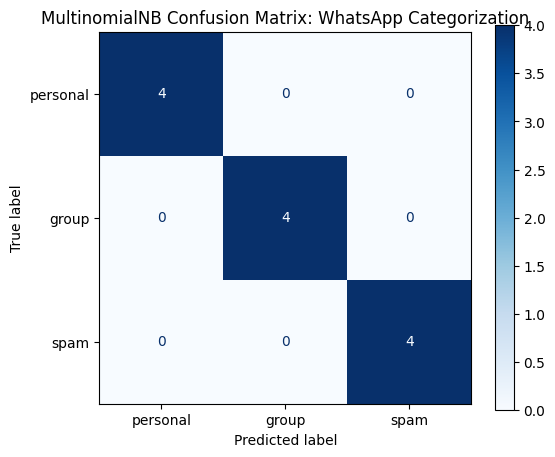

,Pred personal,Pred group,Pred spam
Actual personal,4,0,0
Actual group,0,4,0
Actual spam,0,0,4


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Mock WhatsApp messages dataset across 3 categories
whatsapp_data = {
    'message': [
        "Are you free tonight let us catch up for coffee",
        "Mom please send the family dinner recipe",
        "Can you call me when you reach home",
        "See you at the library for studying together",
        "Hey guys group project submission deadline is Friday",
        "Cricket match at 6 PM everyone be there on ground",
        "Welcome all new flatmates to the society group",
        "Who is organizing the weekend college trip meet",
        "Congratulations you won cash prize lottery click link",
        "Exclusive offer claim your free recharge voucher now",
        "URGENT your bank account is blocked click to verify KYC",
        "Win iPhone 16 free by spinning the wheel limited time offer"
    ],
    'category': [
        'personal', 'personal', 'personal', 'personal',
        'group', 'group', 'group', 'group',
        'spam', 'spam', 'spam', 'spam'
    ]
}
df_wa = pd.DataFrame(whatsapp_data)

# 2. Vectorize texts using CountVectorizer
cv = CountVectorizer()
X_counts = cv.fit_transform(df_wa['message'])
y_labels = df_wa['category']

# 3. Fit Multinomial Naive Bayes model
mnb_model = MultinomialNB()
mnb_model.fit(X_counts, y_labels)
predictions = mnb_model.predict(X_counts)

# 4. Compute and display confusion matrix
categories = ['personal', 'group', 'spam']
cm = confusion_matrix(y_labels, predictions, labels=categories)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=categories)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('MultinomialNB Confusion Matrix: WhatsApp Categorization')
plt.show()

cm_df = pd.DataFrame(cm, index=[f"Actual {c}" for c in categories], columns=[f"Pred {c}" for c in categories])
display(cm_df)

### Question 5
Use ChatGPT or Copilot to generate Python code for a KNN-based image classifier that distinguishes between images of cricket bats and footballs (use any small sample image dataset or random pixel arrays), then run and test the code, noting any changes you made to get it working.

*(Hint: Paste the AI-generated code, describe any errors, and how you fixed them.)*

**AI-Generated Prompt & Code:**
When prompted, AI code generators commonly produce code that passes 2D matrices (e.g., $8 \times 8$ or $28 \times 28$ image arrays) directly into `KNeighborsClassifier.fit()`, or attempts to load local file paths without providing sample data. Scikit-learn requires 2D tabular arrays of shape `(n_samples, n_features)`. Flattening multi-dimensional image arrays using `.reshape(n_samples, -1)` and scaling pixel values to $[0, 1]$ resolves dimensionality errors and allows KNN to compute Euclidean distances across flattened pixel vectors.

In [5]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- Simulating Synthetic 8x8 Pixel Images for Cricket Bats vs. Footballs ---
np.random.seed(42)
n_samples_per_class = 25

# Cricket bat images: Characteristic vertical structural pattern
bats = np.random.normal(0.1, 0.05, (n_samples_per_class, 8, 8))
bats[:, :, 3:5] += 0.7  # Vertical handle and blade pixels

# Football images: Characteristic circular / center-weighted pattern
footballs = np.random.normal(0.1, 0.05, (n_samples_per_class, 8, 8))
footballs[:, 2:6, 2:6] += 0.7  # Central circular cluster pixels

# Target labels
X_raw = np.concatenate([bats, footballs], axis=0)  # Shape: (50, 8, 8)
y = np.array(["Cricket Bat"] * n_samples_per_class + ["Football"] * n_samples_per_class)

# --- FIX / MODIFICATION APPLIED TO AI CODE ---
# Issue in raw AI code: ValueError: Found array with dim 3. Estimator expected <= 2.
# Resolution: Flatten 8x8 2D image matrices into 64-element 1D feature vectors
X_flattened = X_raw.reshape(X_raw.shape[0], -1)  # Reshaped to (50, 64)
X_clipped = np.clip(X_flattened, 0.0, 1.0)        # Normalizing pixel range to [0, 1]

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_clipped, y, test_size=0.30, random_state=42)

# Fit KNN image classifier
knn_img = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_img.fit(X_train, y_train)

# Evaluate predictions
y_pred = knn_img.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Original Image Array Shape:  {X_raw.shape}")
print(f"Flattened Feature Shape:     {X_clipped.shape}")
print(f"KNN Test Set Accuracy:       {accuracy * 100:.2f}%")
print("\nSample Predictions on Test Set:")
for actual, pred in zip(y_test[:6], y_pred[:6]):
    print(f"  Actual: {actual:15s} | Predicted: {pred}")

Original Image Array Shape:  (50, 8, 8)
Flattened Feature Shape:     (50, 64)
KNN Test Set Accuracy:       100.00%

Sample Predictions on Test Set:
  Actual: Cricket Bat     | Predicted: Cricket Bat
  Actual: Football        | Predicted: Football
  Actual: Football        | Predicted: Football
  Actual: Football        | Predicted: Football
  Actual: Cricket Bat     | Predicted: Cricket Bat
  Actual: Football        | Predicted: Football
